Dataset link :
https://www.kaggle.com/datasets/tanayatipre/quikr-cars-cleaned-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

In [2]:
df =pd.read_csv('car.csv')
df.sample(7)

,Unnamed: 0,name,company,year,price,kms_driven,fuel_type
192,192,Maruti Suzuki Wagon,Maruti,2011,210000,35000,Petrol
524,524,Maruti Suzuki Dzire,Maruti,2013,380000,35000,Petrol
187,187,Hyundai Creta 1.6,Hyundai,2017,895000,32000,Petrol
379,379,Tata Indigo LX,Tata,2016,130000,104000,Diesel
52,52,Maruti Suzuki Wagon,Maruti,2013,105000,39000,Petrol
212,212,Maruti Suzuki Alto,Maruti,2015,219000,5000,Petrol
489,489,Maruti Suzuki Ritz,Maruti,2010,149000,40000,Petrol


In [17]:
df = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')

In [18]:
df.info()
#df.duplicated().sum()
#df['fuel_type'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        815 non-null    str  
 1   company     815 non-null    str  
 2   year        815 non-null    int64
 3   price       815 non-null    int64
 4   kms_driven  815 non-null    int64
 5   fuel_type   815 non-null    str  
dtypes: int64(3), str(3)
memory usage: 38.3 KB


In [20]:
X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (815, 5)
y shape: (815,)


In [21]:
categorical_cols = ["name", "company", "fuel_type"]
numerical_cols = ["year", "kms_driven"]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['name', 'company', 'fuel_type']
Numerical: ['year', 'kms_driven']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (652, 5)
Testing data: (163, 5)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [25]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [26]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully!")

Linear Regression trained successfully!
Ridge Regression trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!
Extra Trees trained successfully!


In [27]:
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    print(f"{name} prediction completed!")

Linear Regression prediction completed!
Ridge Regression prediction completed!
Random Forest prediction completed!
Gradient Boosting prediction completed!
Extra Trees prediction completed!


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  148128.813097  294822.728085  0.573168
1   Ridge Regression  236751.807164  422556.937461  0.123190
2      Random Forest  123209.026541  304935.595126  0.543384
3  Gradient Boosting  155954.119120  319234.033737  0.499559
4        Extra Trees  115728.439371  308009.907672  0.534131


In [29]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  148128.813097  294822.728085  0.573168
2      Random Forest  123209.026541  304935.595126  0.543384
4        Extra Trees  115728.439371  308009.907672  0.534131
3  Gradient Boosting  155954.119120  319234.033737  0.499559
1   Ridge Regression  236751.807164  422556.937461  0.123190


In [30]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [31]:
new_car = pd.DataFrame({
    "name": ["Maruti Suzuki Ritz"],
    "company": ["Maruti"],
    "year": [2010],
    "kms_driven": [40000],
    "fuel_type": ["Petrol"]
})

In [32]:
predicted_price = best_model.predict(new_car)

print("Predicted Price:", predicted_price[0])

Predicted Price: 169156.4595619589


In [33]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_model.predict(X_test)
})

print(comparison.head(20))

    Actual Price  Predicted Price
0         135000     3.019480e+04
1         284999     3.976950e+05
2         245000     4.016190e+05
3         245000     4.778913e+05
4         499000     3.971279e+05
5         325000     4.506249e+05
6         135000     9.849281e+04
7         174999     2.437534e+05
8         574999     4.596578e+05
9         300000     1.996697e+05
10        315000     3.823069e+05
11        160000     3.283282e+05
12       1000000     6.913955e+05
13        110000     1.920525e+05
14       1891111     2.036026e+06
15        395000     3.652339e+05
16        689999     6.128654e+05
17        195000     3.498143e+05
18       2800000     9.432237e+05
19        140000     2.490720e+05


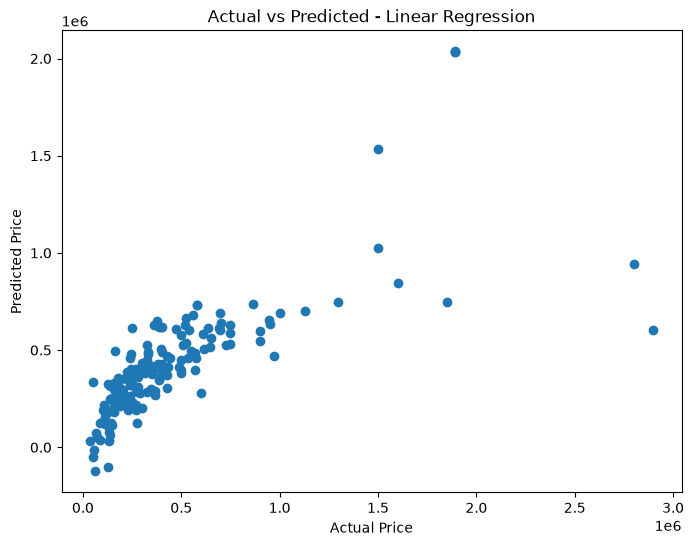

In [34]:
import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_best)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.show()

In [35]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [36]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['name','company','year','kms_driven','fuel_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with th

In [37]:
xgb_pred = xgb_pipeline.predict(X_test)

In [38]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2  :", xgb_r2)

XGBoost
MAE : 124143.78125
RMSE: 294988.295686456
R2  : 0.5726886987686157


In [39]:
results_df.loc[len(results_df)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

print(
    results_df.sort_values(
        by="R2 Score",
        ascending=False
    )
)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  148128.813097  294822.728085  0.573168
5            XGBoost  124143.781250  294988.295686  0.572689
2      Random Forest  123209.026541  304935.595126  0.543384
4        Extra Trees  115728.439371  308009.907672  0.534131
3  Gradient Boosting  155954.119120  319234.033737  0.499559
1   Ridge Regression  236751.807164  422556.937461  0.123190


In [42]:
for name, model in trained_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    print(f"\n{name}")
    print("Train R2:", train_r2)
    print("Test R2 :", test_r2)
    print("Train MAE:", train_mae)
    print("Test MAE :", test_mae)


Linear Regression
Train R2: 0.7856494319686673
Test R2 : 0.5731682539039735
Train MAE: 106817.96449202007
Test MAE : 148128.8130974055

Ridge Regression
Train R2: 0.1280049060394911
Test R2 : 0.12319046380289744
Train MAE: 207846.09480467517
Test MAE : 236751.80716418097

Random Forest
Train R2: 0.9519864984683379
Test R2 : 0.543384092749273
Train MAE: 37121.9354990201
Test MAE : 123209.02654114325

Gradient Boosting
Train R2: 0.8713044803579906
Test R2 : 0.49955867749026106
Train MAE: 99378.53986157975
Test MAE : 155954.11912048422

Extra Trees
Train R2: 0.9998515316831516
Test R2 : 0.5341306216633306
Train MAE: 599.6180981595095
Test MAE : 115728.43937116564


# Overfitting Model
